The Sample Superstore Dataset contains transactional data of a retail business, including details such as sales, profit, customer segments, regions, product categories, and discounts.

The objective of this analysis is to explore the dataset and identify key business insights that can help improve overall performance. The analysis focuses on understanding sales trends, profit distribution, customer behavior, and the impact of discounts on profitability.





1.   Packages Import
2.   data ingestion



In [10]:
#packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#data ingestion
df = pd.read_csv('/content/SampleSuperstore.csv')

#data show of
df.head(5)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [14]:
#data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


## 📊 Dataset Overview Summary

The Sample Superstore dataset consists of **9,994 records** and **13 columns**, representing transactional data of a retail business. Each row corresponds to an individual sales transaction.

### 🔹 Data Structure

* Total Entries: **9994**
* Total Columns: **13**
* Memory Usage: **~1015 KB**

### 🔹 Data Types

* **Object (Categorical Data): 8 columns**
  These include:

  * Ship Mode
  * Segment
  * Country
  * City
  * State
  * Region
  * Category
  * Sub-Category

  👉 These columns help in grouping and analyzing business performance across different dimensions.

* **Integer (Numerical Data): 2 columns**

  * Postal Code
  * Quantity

  👉 Quantity represents the number of items sold per transaction.

* **Float (Continuous Numerical Data): 3 columns**

  * Sales
  * Discount
  * Profit

  👉 These are the most important columns for financial analysis.

### 🔹 Data Quality

* All columns have **9994 non-null values**, indicating:
  ✅ No missing values
  ✅ Clean dataset ready for analysis

### 🔹 Key Insights About the Data

* The dataset includes both **categorical and numerical features**, making it suitable for detailed analysis.
* It allows analysis across multiple dimensions such as:

  * Geography (City, State, Region)
  * Customer Segments
  * Product Categories
* Financial performance can be evaluated using:

  * Sales
  * Profit
  * Discount

### 🔹 Conclusion

The dataset is well-structured and clean, with no missing values. It provides sufficient information to perform exploratory data analysis (EDA), identify trends, and generate actionable business insights related to sales performance, profitability, and customer behavior.


In [15]:
#Basic overview
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Orders:", df.shape[0])
print("Average Sales:", df["Sales"].mean())

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 9994
Average Sales: 229.85800083049833


The analysis of the dataset provides an overview of the business performance through key metrics such as total sales, total profit, number of orders, and average sales per order.

Total Sales represents the overall revenue generated from all transactions, indicating the scale of business operations.

Total Profit shows the net earnings after accounting for costs and discounts, helping evaluate overall profitability.

Total Orders indicates the volume of transactions, reflecting customer activity and demand.

Average Sales gives insight into the typical value of each order, helping understand customer purchasing behavior.

In [16]:
#Category analysis
category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()
print(category_analysis)

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


📊 Category Analysis Summary

This analysis groups the data by Category and calculates the total Sales and Profit for each category.

It provides a high-level view of how each category contributes to overall revenue and profitability.

It helps identify the most profitable category as well as categories that may have lower profit margins.

By comparing sales and profit together, it becomes easier to understand whether high sales are translating into actual profit.

In [17]:
#Sub-category analysis
subcat_analysis = df.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
print(subcat_analysis)

                    Sales      Profit
Sub-Category                         
Phones        330007.0540  44515.7306
Chairs        328449.1030  26590.1663
Storage       223843.6080  21278.8264
Tables        206965.5320 -17725.4811
Binders       203412.7330  30221.7633
Machines      189238.6310   3384.7569
Accessories   167380.3180  41936.6357
Copiers       149528.0300  55617.8249
Bookcases     114879.9963  -3472.5560
Appliances    107532.1610  18138.0054
Furnishings    91705.1640  13059.1436
Paper          78479.2060  34053.5693
Supplies       46673.5380  -1189.0995
Art            27118.7920   6527.7870
Envelopes      16476.4020   6964.1767
Labels         12486.3120   5546.2540
Fasteners       3024.2800    949.5182


📊 Sub-Category Analysis Summary
This analysis groups the data by Sub-Category and calculates the total Sales and Profit for each, sorted by highest sales.

It helps identify top-performing sub-categories that generate the most revenue.

It also highlights profitability, showing which products contribute most to earnings.

Some sub-categories may show high sales but low or negative profit, indicating potential issues like high discounts or costs.


In [19]:
#Region analysis
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum()
print(region_analysis)

               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489


📊 Region Analysis Summary

This analysis groups the data by Region and calculates the total Sales and Profit for each region.

It helps identify which regions are generating the highest revenue and profit.

It also highlights regions that may be underperforming or experiencing losses.

By comparing sales and profit, it becomes easier to evaluate the overall business performance across different geographical areas.

In [20]:
#State Analysis
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
print(state_sales)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


📊 Top States by Sales Summary

This analysis identifies the top 10 states based on total Sales, sorted in descending order.

It highlights the states that contribute the highest revenue to the business.

These states represent key markets where demand is strong and business performance is high.

Focusing on these regions can help in maximizing sales and expanding market presence.

In [21]:
#Segment analysis
segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum()
print(segment_analysis)

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785


📊 Segment Analysis Summary

This analysis groups the data by Customer Segment and calculates total Sales and Profit for each segment.

It helps identify which customer segment contributes the most to revenue and profitability.

It provides insights into customer behavior and purchasing patterns across segments.

By comparing sales and profit, it becomes easier to determine the most valuable customer group for the business.

In [22]:
#Discount impact
discount_analysis = df.groupby("Discount")["Profit"].mean()
print(discount_analysis)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


This analysis groups the data by Discount and calculates the average Profit for each discount level.

It helps understand how different discount rates impact profitability.

Higher discounts often result in lower or negative average profit, indicating reduced margins.

Lower or no discounts tend to maintain better profitability.

In [24]:
#Correlation (Sales vs Profit)
correlation = df[["Sales", "Profit"]].corr()
print(correlation)

           Sales    Profit
Sales   1.000000  0.479064
Profit  0.479064  1.000000


📊 Sales vs Profit Correlation Summary
This analysis calculates the correlation between Sales and Profit to understand their relationship.

It shows whether an increase in sales leads to an increase in profit.

A positive correlation indicates that higher sales generally result in higher profit.

A weak or negative correlation suggests that high sales do not always guarantee profitability, possibly due to factors like discounts or high costs.

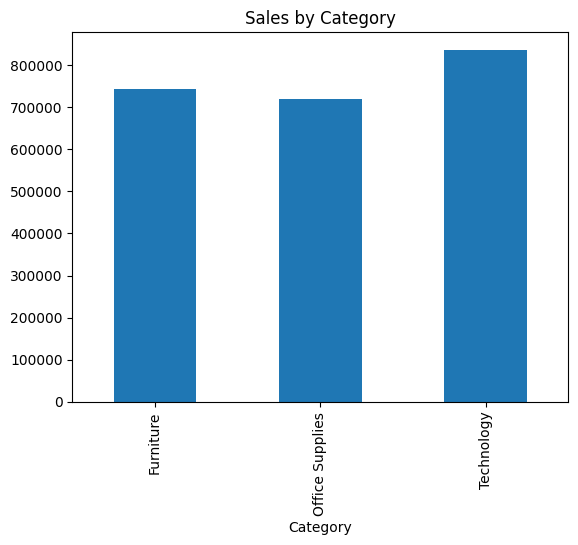

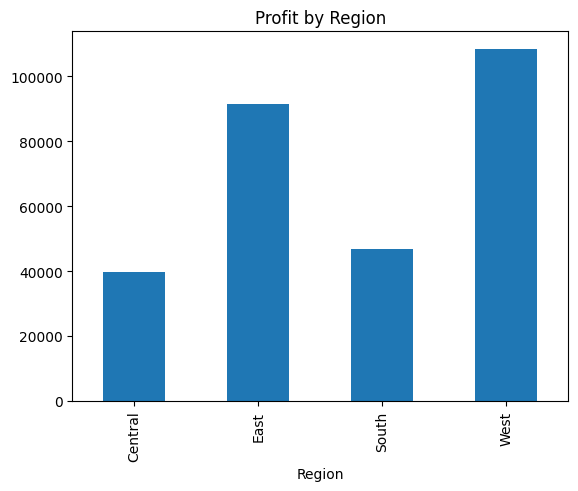

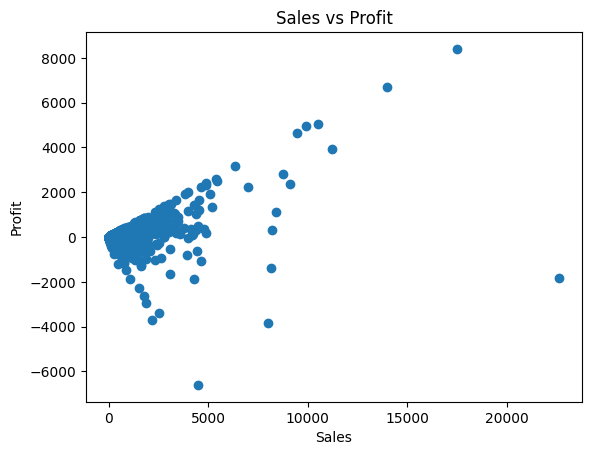

In [25]:
# Category Sales Chart
df.groupby("Category")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.show()

# Profit by Region
df.groupby("Region")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Region")
plt.show()

# Sales vs Profit Scatter
plt.scatter(df["Sales"], df["Profit"])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

📊 Visualization Summary

The visualizations provide a clear understanding of sales distribution, regional profitability, and the relationship between sales and profit.

The Sales by Category (Bar Chart) highlights how revenue is distributed across different product categories, helping identify the highest-selling category.

The Profit by Region (Bar Chart) shows the profitability across regions, making it easy to compare performance and identify top and underperforming regions.

The Sales vs Profit (Scatter Plot) illustrates the relationship between sales and profit, helping to detect patterns such as high sales with low or negative profit.

In [26]:
# High discount but loss
high_discount_loss = df[(df["Discount"] > 0.3) & (df["Profit"] < 0)]
print(high_discount_loss.head())

         Ship Mode      Segment        Country             City         State  \
3   Standard Class     Consumer  United States  Fort Lauderdale       Florida   
14  Standard Class  Home Office  United States       Fort Worth         Texas   
15  Standard Class  Home Office  United States       Fort Worth         Texas   
27  Standard Class     Consumer  United States     Philadelphia  Pennsylvania   
28  Standard Class     Consumer  United States     Philadelphia  Pennsylvania   

    Postal Code   Region         Category Sub-Category      Sales  Quantity  \
3         33311    South        Furniture       Tables   957.5775         5   
14        76106  Central  Office Supplies   Appliances    68.8100         5   
15        76106  Central  Office Supplies      Binders     2.5440         3   
27        19140     East        Furniture    Bookcases  3083.4300         7   
28        19140     East  Office Supplies      Binders     9.6180         2   

    Discount     Profit  
3       0.45

## 📊 High Discount but Loss Analysis Summary

This analysis filters transactions where the **discount is greater than 30%** and the **profit is negative**.

* It helps identify cases where **high discounts are leading to losses**.
* These transactions indicate that excessive discounting is negatively impacting profitability.
* It highlights the need to **optimize discount strategies** to avoid selling products at a loss.

Overall, this analysis reveals a critical business issue where higher discounts may reduce profit margins and lead to financial losses, guiding better pricing decisions.


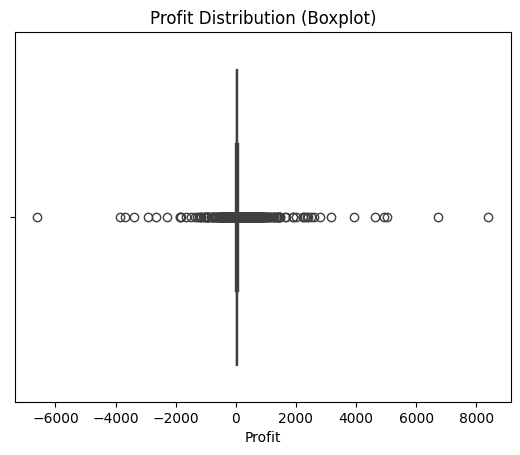

In [27]:
#Boxplot (Outliers Detection)
sns.boxplot(x=df["Profit"])
plt.title("Profit Distribution (Boxplot)")
plt.show()

📊 Profit Distribution (Boxplot) Summary

This boxplot visualizes the distribution of Profit and helps identify outliers in the dataset.

The central box represents the middle 50% of profit values (IQR).

The line inside the box shows the median profit.

Points outside the whiskers represent outliers, indicating unusually high profits or significant losses.

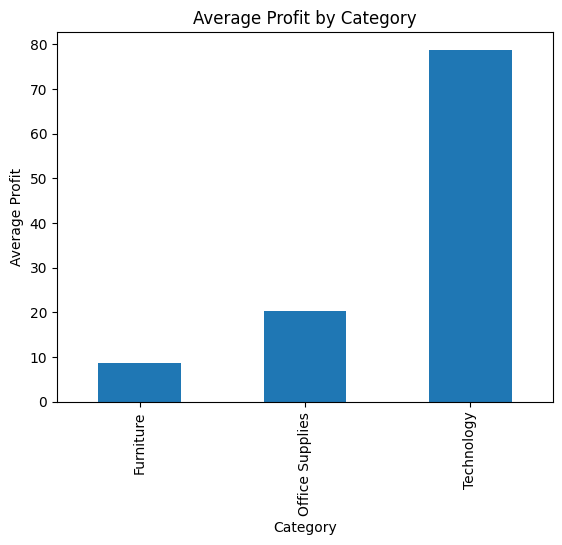

In [28]:
#Average Profit by Category (Bar)
df.groupby("Category")["Profit"].mean().plot(kind="bar")
plt.title("Average Profit by Category")
plt.xlabel("Category")
plt.ylabel("Average Profit")
plt.show()

📊 Average Profit by Category Summary

This bar chart shows the average profit for each product category.

It helps compare how profitable each category is on average, rather than total profit.

Categories with higher average profit indicate better margin per sale.

Categories with lower or negative average profit may indicate pricing or discount issues.

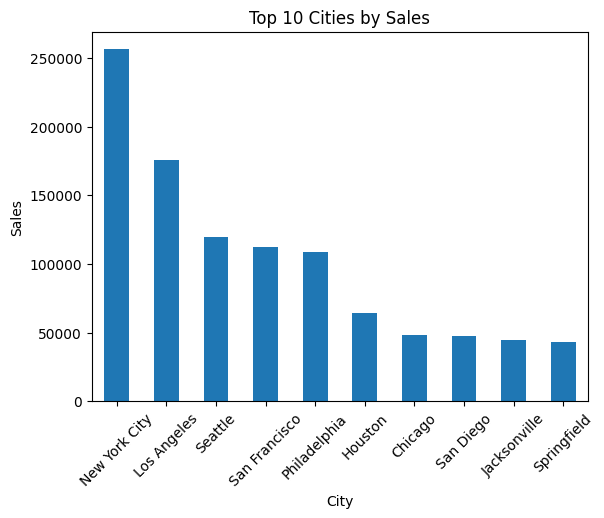

In [29]:
#Top 10 Cities by Sales
df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

📊 Top 10 Cities by Sales Summary

This bar chart displays the top 10 cities based on total Sales.

It highlights the cities that generate the highest revenue for the business.

These cities represent key markets with strong customer demand.

The comparison helps identify where the company is performing best geographically.

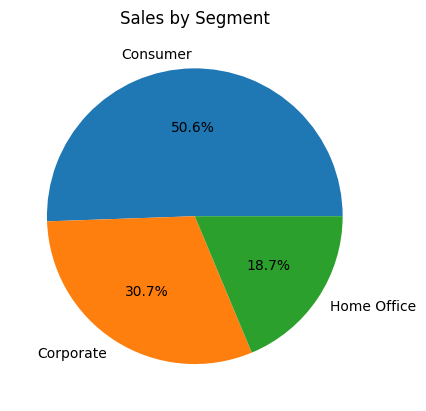

In [30]:
#Sales by Segment (Pie Chart)
df.groupby("Segment")["Sales"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("Sales by Segment")
plt.ylabel("")
plt.show()

📊 Sales by Segment (Pie Chart) Summary

This pie chart represents the distribution of Sales across different customer segments.

It shows the percentage contribution of each segment (Consumer, Corporate, Home Office) to total sales.

Helps identify which segment generates the highest revenue share.

Provides insight into customer demand patterns across segments.

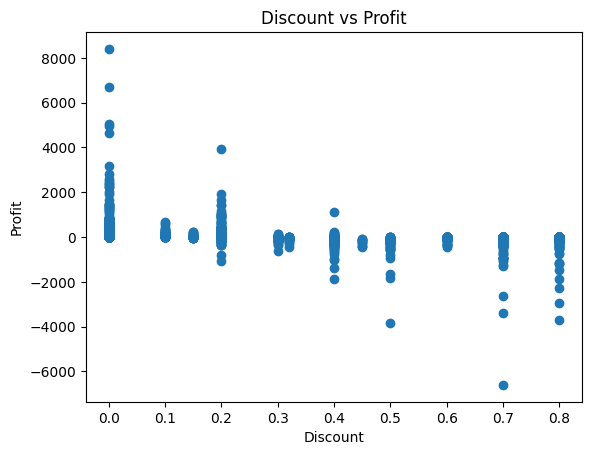

In [31]:
# Discount vs Profit (Scatter - Clear View)
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

#📊 Discount vs Profit (Scatter Plot) Summary

This scatter plot shows the relationship between Discount and Profit.

It helps visualize how increasing discounts impact profitability.

A clear pattern often shows that higher discounts lead to lower or negative profit.

Points spread across the graph indicate variations in profit at different discount levels.

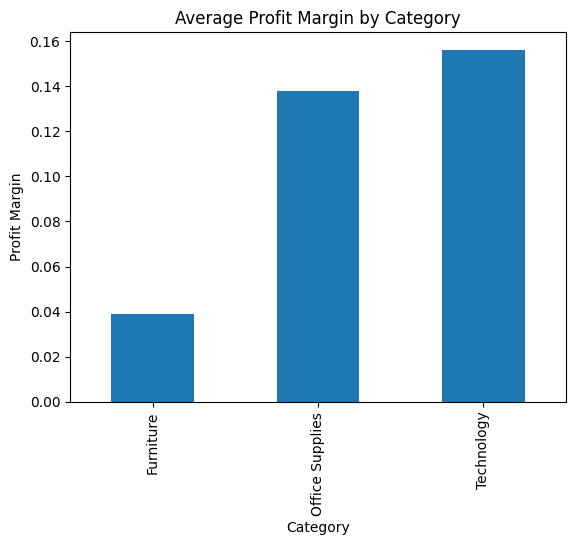

In [32]:
#Profit Margin Calculation
df["Profit Margin"] = df["Profit"] / df["Sales"]

df.groupby("Category")["Profit Margin"].mean().plot(kind="bar")
plt.title("Average Profit Margin by Category")
plt.ylabel("Profit Margin")
plt.show()


#📊 Profit Margin Analysis Summary

This analysis calculates the Profit Margin (Profit divided by Sales) and visualizes the average profit margin by category.

It shows how much profit is earned for each unit of sales in different categories.

Categories with higher profit margins indicate better efficiency and profitability per sale.

Lower profit margins may suggest higher costs or excessive discounting.

/tmp/ipykernel_2523/1636918671.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_margin = df.groupby("Region").apply(lambda x: x["Profit"].sum()/x["Sales"].sum())


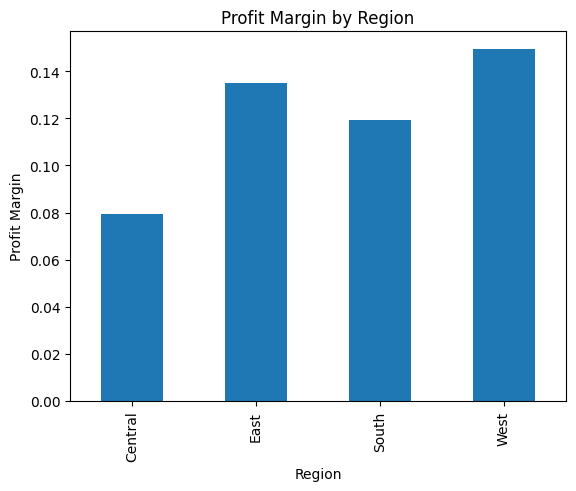

In [33]:
#Region-wise Profit Margin
region_margin = df.groupby("Region").apply(lambda x: x["Profit"].sum()/x["Sales"].sum())

region_margin.plot(kind="bar")
plt.title("Profit Margin by Region")
plt.ylabel("Profit Margin")
plt.show()

#📊 Region-wise Profit Margin Summary

This analysis calculates the profit margin for each region by comparing total profit to total sales.

It helps identify which regions are more efficient in generating profit from sales.

Regions with higher profit margins indicate better cost control and pricing strategies.

Lower profit margins may suggest issues like high discounts or operational inefficiencies.


### 📊 Overall Project Summary (Detailed)

This project analyzes the Sample Superstore dataset to evaluate business performance across sales, profit, customer segments, regions, and product categories. The analysis shows that while the company generates strong sales, profitability is inconsistent due to factors such as high discounts and varying performance across regions and product types.

Key insights reveal that certain categories and sub-categories contribute significantly to revenue, but not all are equally profitable. Regional analysis highlights differences in performance, with some areas generating higher profit margins than others. Customer segment analysis indicates which groups drive the most revenue.

A major finding is the negative impact of high discounts on profit, often leading to losses despite high sales. Visualizations and correlation analysis further support these observations by identifying patterns, outliers, and relationships between variables.

Overall, the study emphasizes the importance of optimizing discount strategies, focusing on high-performing products and regions, and improving cost efficiency to enhance overall profitability and support better business decision-making.
